In [55]:
"""
Cell 0 — Setup: imports, style, color palette, data loading, helper functions.
"""

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT = Path(os.path.dirname(os.path.abspath("__file__")))  # notebook dir = repo root
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ── Academic paper style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,        # screen preview
    'savefig.dpi': 300,       # publication
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Consistent color palette ──────────────────────────────────────────────────
COLORS = {
    'human':    '#2166AC',   # Blue
    'model':    '#E66101',   # Orange
    'bielik':   '#D95F02',   # Dark orange
    'gemma3':   '#7570B3',   # Purple
    'qwen':     '#1B9E77',   # Teal
    'CHN':      '#E7298A',   # Pink/red
    'SVK':      '#66A61E',   # Green
    'USA':      '#E6AB02',   # Gold
    'improved': '#2CA02C',   # Green
    'worsened': '#D62728',   # Red
    'neutral':  '#7F7F7F',   # Gray
    'w1_area':  '#CCCCCC',   # Light gray for shaded W1 area
}

COUNTRY_LABELS = {'CHN': 'China', 'SVK': 'Slovakia', 'USA': 'USA'}
MODEL_LABELS   = {'bielik': 'Bielik-11B', 'gemma3': 'Gemma3-12B', 'qwen': 'Qwen3-4B'}
MODEL_ORIGINS  = {'bielik': 'Poland', 'gemma3': 'USA', 'qwen': 'China'}

# ── Helper functions ──────────────────────────────────────────────────────────
def compute_pmf_from_responses(responses, values=range(1, 11)):
    """Empirical PMF from raw integer responses (1-10)."""
    counts = np.zeros(10)
    for v in responses:
        if 1 <= v <= 10:
            counts[int(v) - 1] += 1
    total = counts.sum()
    return counts / total if total > 0 else counts

def compute_cdf(pmf):
    """CDF from PMF array of length 10."""
    return np.cumsum(pmf)

def w1_from_cdfs(cdf1, cdf2):
    """Raw Wasserstein-1 as integral of |F - G| on 1-10 grid (step width = 1)."""
    return np.sum(np.abs(cdf1 - cdf2))

def save_fig(fig, name):
    """Save figure as PDF + PNG to figures/ directory."""
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"  Saved {name}.pdf  &  {name}.png")

# ── Load data ─────────────────────────────────────────────────────────────────
# Human distributions (pre-computed PMFs)
human_dist = pd.read_csv(ROOT / "data" / "raw" / "human_distributions.csv")
pmf_cols = [f"pmf_{i}" for i in range(1, 11)]

# Baseline analysis
w1_all   = pd.read_csv(ROOT / "results" / "analysis" / "w1_all_combinations.csv")
w1_ci    = pd.read_csv(ROOT / "results" / "analysis" / "w1_bootstrap_ci.csv")
top5     = pd.read_csv(ROOT / "results" / "analysis" / "top5_per_model.csv")
heatmap_data = pd.read_csv(ROOT / "results" / "analysis" / "rq1_model_country_table.csv")

# Post-LoRA analysis
posteval_w1   = pd.read_csv(ROOT / "results" / "analysis_posteval" / "posteval_w1_all.csv")
rq2_comparison = pd.read_csv(ROOT / "results" / "analysis_posteval" / "rq2_worst_case_comparison.csv")
rq3_side       = pd.read_csv(ROOT / "results" / "analysis_posteval" / "rq3_side_effects_comparison.csv")

# Raw responses — baseline (from checkpoints)
baseline_bielik = pd.read_csv(ROOT / "checkpoints" / "baseline_bielik.csv")
baseline_gemma3 = pd.read_csv(ROOT / "checkpoints" / "baseline_gemma3.csv")
baseline_qwen   = pd.read_csv(ROOT / "checkpoints" / "baseline_qwen.csv")
baseline_all = pd.concat([baseline_bielik, baseline_gemma3, baseline_qwen], ignore_index=True)

# Raw responses — post-LoRA
posteval_bielik = pd.read_csv(ROOT / "results" / "posteval" / "bielik_lora_responses.csv")
posteval_qwen   = pd.read_csv(ROOT / "results" / "posteval" / "qwen_lora_responses.csv")
posteval_raw = pd.concat([posteval_bielik, posteval_qwen], ignore_index=True)

# LoRA target persona IDs per model
bielik_targets = list(top5[top5['model'] == 'bielik']['persona_id'])
qwen_targets   = list(top5[top5['model'] == 'qwen']['persona_id'])

print("All data loaded successfully.")
print(f"  Baseline responses : {len(baseline_all):,}")
print(f"  Post-LoRA responses: {len(posteval_raw):,}")
print(f"  Human personas     : {len(human_dist)}")
print(f"  Bielik targets     : {bielik_targets}")
print(f"  Qwen targets       : {qwen_targets}")

All data loaded successfully.
  Baseline responses : 18,900
  Post-LoRA responses: 12,600
  Human personas     : 63
  Bielik targets     : ['USA_Male_30-49_Medium', 'USA_Male_18-29_Medium', 'USA_Male_50-64_Higher', 'USA_Female_18-29_Medium', 'USA_Male_18-29_Higher']
  Qwen targets       : ['CHN_Male_65+_Medium', 'CHN_Male_65+_Lower', 'CHN_Male_65+_Higher', 'CHN_Male_50-64_Lower', 'CHN_Male_30-49_Medium']


  Saved fig1_w1_explanation.pdf  &  fig1_w1_explanation.png


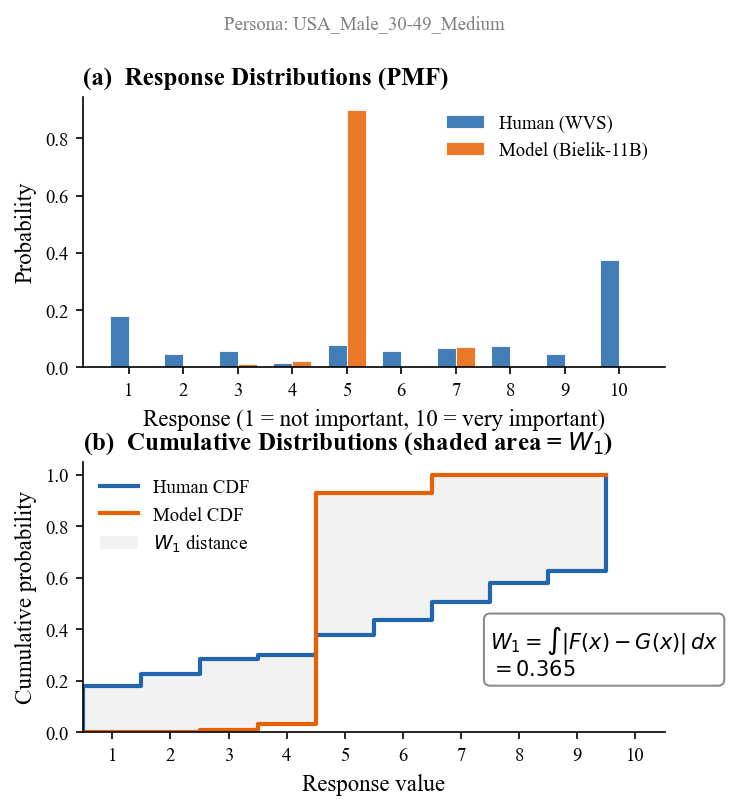

In [56]:
"""
Cell 1 — Figure 1: Wasserstein Distance Explanation
Two-panel figure: (A) PMF overlay, (B) CDF with shaded W₁ area + numeric value.
Example persona: USA_Male_30-49_Medium  ×  Bielik baseline.
"""

persona_id = 'USA_Male_30-49_Medium'

# ── Human PMF (pre-computed) ──────────────────────────────────────────────────
h_row = human_dist[human_dist['persona_id'] == persona_id].iloc[0]
human_pmf = h_row[pmf_cols].values.astype(float)

# ── Model PMF (from raw baseline responses) ──────────────────────────────────
mask = (baseline_bielik['persona_id'] == persona_id)
model_responses = baseline_bielik.loc[mask, 'parsed_value'].values
model_pmf = compute_pmf_from_responses(model_responses)

# ── CDFs ──────────────────────────────────────────────────────────────────────
human_cdf = compute_cdf(human_pmf)
model_cdf = compute_cdf(model_pmf)
w1_raw = w1_from_cdfs(human_cdf, model_cdf)
w1_norm = w1_raw / 9

x = np.arange(1, 11)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5.5), gridspec_kw={'hspace': 0.35})

# ── Panel A: PMF bar chart (NO arrow, NO W1 annotation here) ─────────────────
width = 0.35
ax1.bar(x - width/2, human_pmf, width, color=COLORS['human'],
        label='Human (WVS)', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.bar(x + width/2, model_pmf, width, color=COLORS['model'],
        label='Model (Bielik-11B)', alpha=0.85, edgecolor='white', linewidth=0.5)

ax1.set_xlabel('Response (1 = not important, 10 = very important)')
ax1.set_ylabel('Probability')
ax1.set_xticks(x)
ax1.set_title('(a)  Response Distributions (PMF)', loc='left', fontweight='bold')
ax1.legend(frameon=False)

# ── Panel B: CDF with shaded W₁ area + formula + numeric value ───────────────
x_step = np.repeat(np.arange(0.5, 10.5), 2)
h_step = np.concatenate([[0], np.repeat(human_cdf, 2)[:-1]])
m_step = np.concatenate([[0], np.repeat(model_cdf, 2)[:-1]])

ax2.plot(x_step, h_step, color=COLORS['human'], lw=2, label='Human CDF')
ax2.plot(x_step, m_step, color=COLORS['model'], lw=2, label='Model CDF')
ax2.fill_between(x_step, h_step, m_step, alpha=0.25, color=COLORS['w1_area'],
                 label='$W_1$ distance', edgecolor='none')

# Formula + numeric value together
ax2.text(7.5, 0.22,
         f'$W_1 = \\int |F(x) - G(x)|\\,dx$\n$= {w1_norm:.3f}$',
         fontsize=10, fontstyle='italic',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

ax2.set_xlabel('Response value')
ax2.set_ylabel('Cumulative probability')
ax2.set_xticks(x)
ax2.set_title('(b)  Cumulative Distributions (shaded area = $W_1$)', loc='left', fontweight='bold')
ax2.legend(frameon=False, loc='upper left')
ax2.set_xlim(0.5, 10.5)
ax2.set_ylim(0, 1.05)

fig.suptitle(f'Persona: {persona_id}', fontsize=9, color='gray', y=0.98)

save_fig(fig, 'fig1_w1_explanation')
plt.show()

  Saved fig2_rq1_heatmap.pdf  &  fig2_rq1_heatmap.png


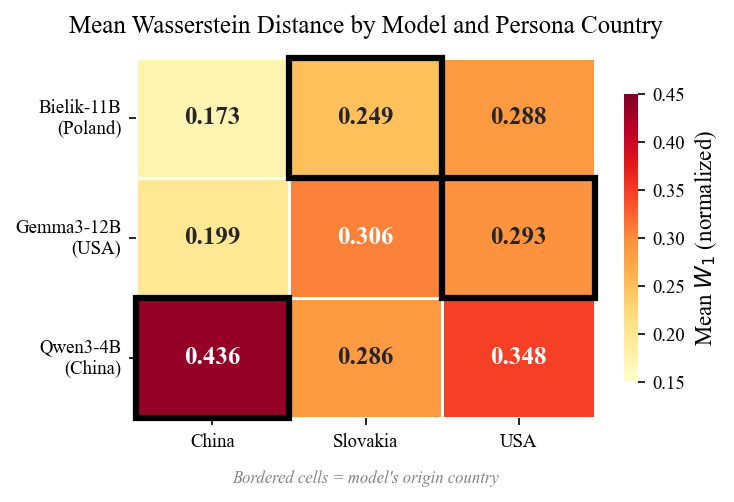

In [57]:
"""
Cell 2 — Figure 2: RQ1 Heatmap — Mean W₁ by Model × Country
Bordered cells = model's origin country.
"""

# Build 3×3 matrix from CSV
df_heat = heatmap_data.set_index('model')[['CHN', 'SVK', 'USA']]
df_heat.index = [f"Bielik-11B\n(Poland)", f"Gemma3-12B\n(USA)", f"Qwen3-4B\n(China)"]
df_heat.columns = ['China', 'Slovakia', 'USA']

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=1.2, linecolor='white',
            cbar_kws={'label': 'Mean $W_1$ (normalized)', 'shrink': 0.8},
            vmin=0.15, vmax=0.45, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})

ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('Mean Wasserstein Distance by Model and Persona Country', pad=12)

# Highlight "origin country" cells with bold black border
# Row 0 = Bielik → SVK (col 1), Row 1 = Gemma3 → USA (col 2), Row 2 = Qwen → CHN (col 0)
origin_cells = [(0, 1), (1, 2), (2, 0)]
for (row, col) in origin_cells:
    ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=False,
                                edgecolor='black', lw=3, clip_on=False))

# Legend note
ax.text(0.5, -0.18, 'Bordered cells = model\'s origin country',
        transform=ax.transAxes, ha='center', fontsize=8, fontstyle='italic', color='gray')

plt.tight_layout()
save_fig(fig, 'fig2_rq1_heatmap')
plt.show()

  Saved fig3_rq2_cdf_comparison.pdf  &  fig3_rq2_cdf_comparison.png


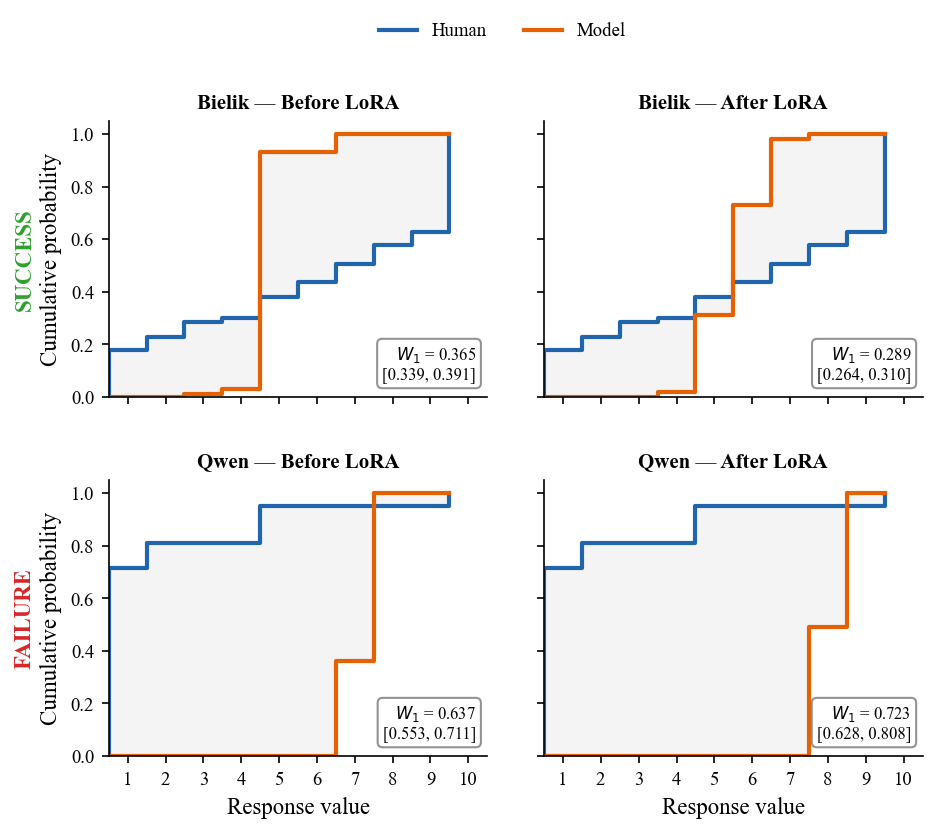

In [58]:
"""
Cell 3 — Figure 3: RQ2 CDF Overlays — Before/After LoRA (2×2 panel)
Top row: Bielik SUCCESS (USA_Male_30-49_Medium)
Bottom row: Qwen FAILURE (CHN_Male_65+_Medium)
"""

def get_model_pmf(df_raw, persona, model_col='model', model_val=None):
    """Get PMF from raw response dataframe for a given persona."""
    mask = (df_raw['persona_id'] == persona)
    if model_val:
        mask &= (df_raw[model_col] == model_val)
    col = 'parsed_value'
    return compute_pmf_from_responses(df_raw.loc[mask, col].values)

def get_w1_info(df_ci, persona, model):
    """Look up W1 norm + CI from analysis CSV."""
    row = df_ci[(df_ci['persona_id'] == persona) & (df_ci['model'] == model)]
    if len(row) == 0:
        return None, None, None
    row = row.iloc[0]
    return row['w1_norm'], row.get('w1_ci_lower', np.nan), row.get('w1_ci_upper', np.nan)

# ── Panel spec ────────────────────────────────────────────────────────────────
panels = {
    (0, 0): ('USA_Male_30-49_Medium', baseline_bielik, 'bielik',
             w1_ci, 'bielik', 'Bielik — Before LoRA'),
    (0, 1): ('USA_Male_30-49_Medium', posteval_bielik, 'bielik_lora',
             posteval_w1, 'bielik_lora', 'Bielik — After LoRA'),
    (1, 0): ('CHN_Male_65+_Medium', baseline_qwen, 'qwen',
             w1_ci, 'qwen', 'Qwen — Before LoRA'),
    (1, 1): ('CHN_Male_65+_Medium', posteval_qwen, 'qwen_lora',
             posteval_w1, 'qwen_lora', 'Qwen — After LoRA'),
}

fig, axes = plt.subplots(2, 2, figsize=(7, 5.5), sharex=True, sharey=True)

for (r, c), (persona, raw_df, model_key, ci_df, ci_model, title) in panels.items():
    ax = axes[r, c]
    
    # Human PMF/CDF
    h_row = human_dist[human_dist['persona_id'] == persona].iloc[0]
    h_pmf = h_row[pmf_cols].values.astype(float)
    h_cdf = compute_cdf(h_pmf)
    
    # Model PMF/CDF
    m_pmf = get_model_pmf(raw_df, persona)
    m_cdf = compute_cdf(m_pmf)
    
    # Step-function coordinates
    x_step = np.repeat(np.arange(0.5, 10.5), 2)
    h_step = np.concatenate([[0], np.repeat(h_cdf, 2)[:-1]])
    m_step = np.concatenate([[0], np.repeat(m_cdf, 2)[:-1]])
    
    ax.plot(x_step, h_step, color=COLORS['human'], lw=2, label='Human')
    ax.plot(x_step, m_step, color=COLORS['model'], lw=2, label='Model')
    ax.fill_between(x_step, h_step, m_step, alpha=0.2, color=COLORS['w1_area'],
                    edgecolor='none')
    
    # W1 annotation
    w1_val, ci_lo, ci_hi = get_w1_info(ci_df, persona, ci_model)
    if w1_val is not None:
        label = f'$W_1$ = {w1_val:.3f}'
        if not np.isnan(ci_lo):
            label += f'\n[{ci_lo:.3f}, {ci_hi:.3f}]'
        ax.text(0.97, 0.05, label, transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85))
    
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlim(0.5, 10.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(1, 11))

# Row labels — SUCCESS / FAILURE
axes[0, 0].annotate('SUCCESS', xy=(-0.22, 0.5), xycoords='axes fraction',
                    fontsize=11, fontweight='bold', color=COLORS['improved'],
                    rotation=90, ha='center', va='center')
axes[1, 0].annotate('FAILURE', xy=(-0.22, 0.5), xycoords='axes fraction',
                    fontsize=11, fontweight='bold', color=COLORS['worsened'],
                    rotation=90, ha='center', va='center')

axes[1, 0].set_xlabel('Response value')
axes[1, 1].set_xlabel('Response value')
axes[0, 0].set_ylabel('Cumulative probability')
axes[1, 0].set_ylabel('Cumulative probability')

# Shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02), fontsize=9)

fig.subplots_adjust(hspace=0.3, wspace=0.15)
save_fig(fig, 'fig3_rq2_cdf_comparison')
plt.show()

  Saved fig4_rq3_redistribution_bielik.pdf  &  fig4_rq3_redistribution_bielik.png


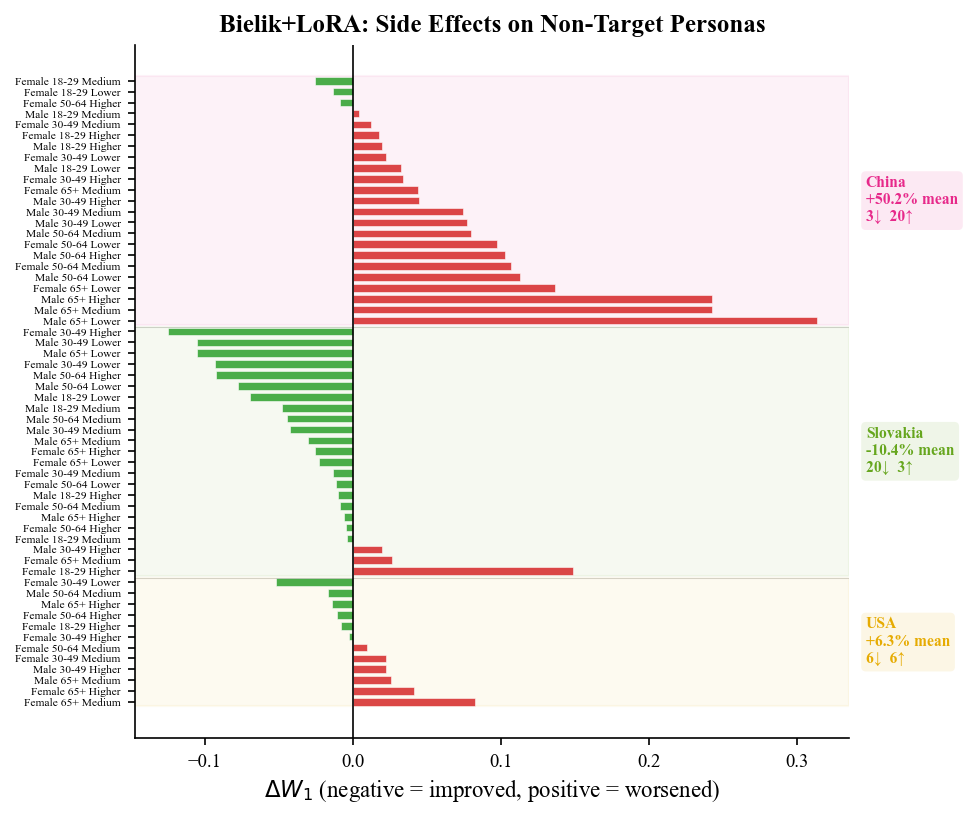

In [59]:
"""
Cell 4 — Figure 4: RQ3 Redistribution Effect — Bielik (Diverging Bar Chart)
Shows ΔW₁ for each non-target persona, grouped by country.
"""

def make_redistribution_plot(df_side, model_name, targets, title, fig_name):
    """Diverging horizontal bar chart of side-effects for one model."""
    # Filter to model, exclude target personas
    df = df_side[df_side['model'] == model_name].copy()
    df = df[~df['persona_id'].isin(targets)].copy()
    df['country'] = df['persona_id'].str[:3]
    
    # Sort: by country, then by delta within country
    country_order = ['CHN', 'SVK', 'USA']
    df['country_rank'] = df['country'].map({c: i for i, c in enumerate(country_order)})
    df = df.sort_values(['country_rank', 'delta']).reset_index(drop=True)
    
    # Assign bar colors
    df['color'] = df['delta'].apply(
        lambda x: COLORS['improved'] if x < 0 else COLORS['worsened'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.subplots_adjust(right=0.72)
    
    y_pos = np.arange(len(df))
    ax.barh(y_pos, df['delta'], color=df['color'], height=0.7, alpha=0.85,
            edgecolor='white', linewidth=0.3)
    
    # Vertical zero line
    ax.axvline(x=0, color='black', lw=0.8, zorder=3)
    
    # Country group shading + right-margin summary
    x_right = ax.get_xlim()[1]  # will use data coords for x, y_pos coords for y
    
    for country in country_order:
        group = df[df['country'] == country]
        if len(group) == 0:
            continue
        idx_start = group.index[0]
        idx_end = group.index[-1]
        
        bg_color = COLORS[country]
        ax.axhspan(idx_start - 0.4, idx_end + 0.4, alpha=0.06, color=bg_color, zorder=0)
        if idx_start > 0:
            ax.axhline(y=idx_start - 0.4, color='gray', lw=0.5, ls='-', alpha=0.3)
        
        # Country summary — use axes data coordinates for y position
        mean_pct = group['pct_change'].mean()
        n_imp = (group['delta'] < 0).sum()
        n_wor = (group['delta'] > 0).sum()
        
        sign = '+' if mean_pct > 0 else ''
        mid_y = (idx_start + idx_end) / 2
        
        # Use annotate with data coordinates for y, axes fraction for x
        ax.annotate(
            f'{COUNTRY_LABELS[country]}\n{sign}{mean_pct:.1f}% mean\n{n_imp}\u2193  {n_wor}\u2191',
            xy=(1.0, mid_y),  # anchor point in data-y, axes-x
            xycoords=('axes fraction', 'data'),
            xytext=(8, 0), textcoords='offset points',
            ha='left', va='center', fontsize=7.5,
            fontweight='bold', color=bg_color,
            bbox=dict(boxstyle='round,pad=0.3', fc=bg_color, alpha=0.1, ec='none'))
    
    # Short persona labels on y-axis
    short_labels = [p.replace('_', ' ').replace('CHN ', '').replace('SVK ', '').replace('USA ', '')
                    for p in df['persona_id']]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(short_labels, fontsize=5.5)
    ax.set_xlabel('$\\Delta W_1$ (negative = improved, positive = worsened)')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    
    save_fig(fig, fig_name)
    plt.show()

make_redistribution_plot(
    rq3_side, 'bielik', bielik_targets,
    'Bielik+LoRA: Side Effects on Non-Target Personas',
    'fig4_rq3_redistribution_bielik'
)

  Saved fig5_before_after_violin.pdf  &  fig5_before_after_violin.png


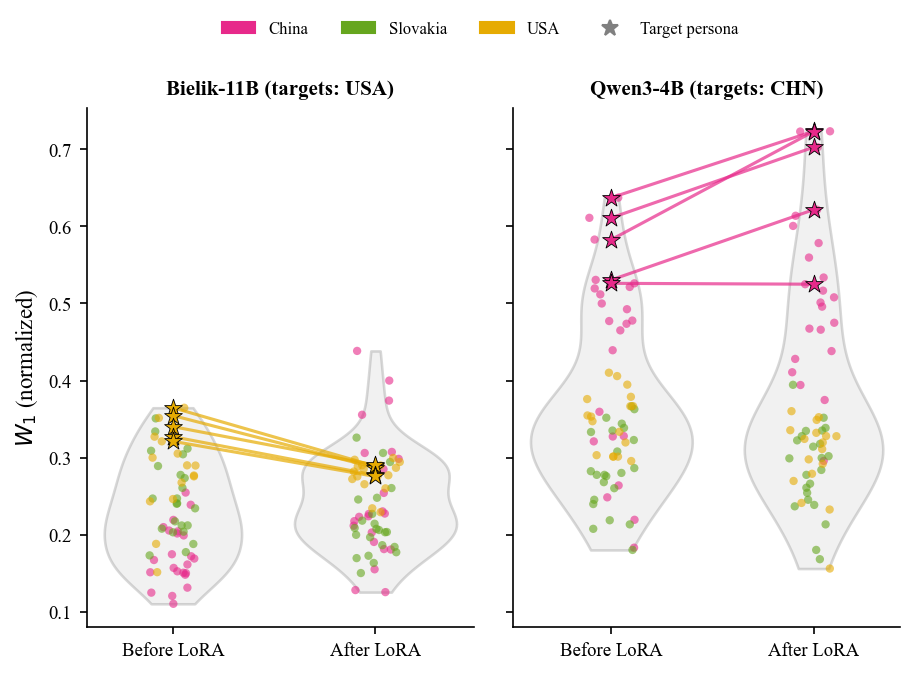

In [60]:
"""
Cell 5 — Figure 5: Before/After Violin Plots (Bielik | Qwen)
Strip + violin overlays coloured by country. Target personas connected with lines
in their COUNTRY color (not improved/worsened color).
"""

def build_combined_df(base_model, lora_model, target_ids):
    """Merge baseline + post-LoRA W1 data for one model pair."""
    base = w1_ci[w1_ci['model'] == base_model][['persona_id', 'w1_norm', 'country']].copy()
    base['phase'] = 'Before LoRA'
    post = posteval_w1[posteval_w1['model'] == lora_model][['persona_id', 'w1_norm', 'country']].copy()
    post['phase'] = 'After LoRA'
    combined = pd.concat([base, post], ignore_index=True)
    combined['is_target'] = combined['persona_id'].isin(target_ids)
    return combined

bielik_comb = build_combined_df('bielik', 'bielik_lora', bielik_targets)
qwen_comb   = build_combined_df('qwen', 'qwen_lora', qwen_targets)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4.5), sharey=True)

phase_order = ['Before LoRA', 'After LoRA']
country_palette = {c: COLORS[c] for c in ['CHN', 'SVK', 'USA']}

for ax, df_comb, model_title, targets in [
    (ax1, bielik_comb, 'Bielik-11B (targets: USA)', bielik_targets),
    (ax2, qwen_comb,   'Qwen3-4B (targets: CHN)', qwen_targets),
]:
    # Violin background
    sns.violinplot(data=df_comb, x='phase', y='w1_norm', order=phase_order,
                   inner=None, color='lightgray', alpha=0.3, ax=ax, cut=0)
    
    # Strip dots coloured by country
    sns.stripplot(data=df_comb, x='phase', y='w1_norm', hue='country',
                  order=phase_order, palette=country_palette,
                  dodge=False, alpha=0.6, size=4, ax=ax, jitter=0.12)
    
    # Connect target personas with lines — USE COUNTRY COLOR
    for pid in targets:
        before = df_comb[(df_comb['persona_id'] == pid) & (df_comb['phase'] == 'Before LoRA')]
        after  = df_comb[(df_comb['persona_id'] == pid) & (df_comb['phase'] == 'After LoRA')]
        if len(before) and len(after):
            y0 = before['w1_norm'].values[0]
            y1 = after['w1_norm'].values[0]
            country = before['country'].values[0]
            color = COLORS[country]
            ax.plot([0, 1], [y0, y1], color=color, lw=1.5, alpha=0.7, zorder=5)
            ax.scatter([0], [y0], marker='*', s=80, color=color, zorder=6,
                       edgecolors='black', linewidth=0.4)
            ax.scatter([1], [y1], marker='*', s=80, color=color, zorder=6,
                       edgecolors='black', linewidth=0.4)
    
    ax.set_title(model_title, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.get_legend().remove()

ax1.set_ylabel('$W_1$ (normalized)')

# Shared legend
handles = [mpatches.Patch(color=COLORS[c], label=COUNTRY_LABELS[c]) for c in ['CHN', 'SVK', 'USA']]
handles.append(plt.Line2D([0], [0], marker='*', color='gray', markersize=8,
                           label='Target persona', linestyle='None'))
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.03), fontsize=8)

fig.subplots_adjust(wspace=0.1)
save_fig(fig, 'fig5_before_after_violin')
plt.show()

  Saved fig6_top5_turnover.pdf  &  fig6_top5_turnover.png


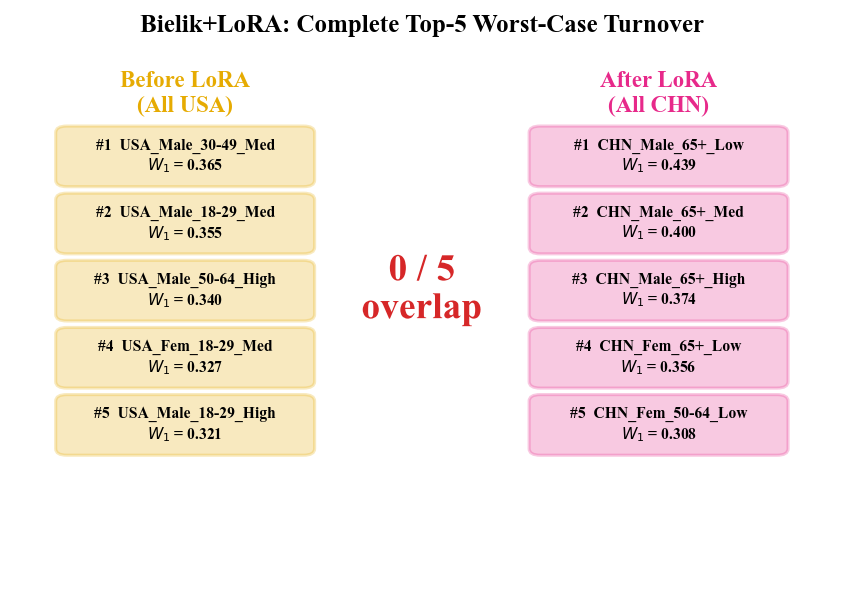

In [61]:
"""
Cell 6 — Figure 6: Worst-Case Turnover — Bielik Top-5 Before vs After LoRA
Boxes only, NO connecting arrows. 0/5 overlap = complete disconnect.
"""
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

before_top5 = [
    ('USA_Male_30-49_Med',   0.365),
    ('USA_Male_18-29_Med',   0.355),
    ('USA_Male_50-64_High',  0.340),
    ('USA_Fem_18-29_Med',    0.327),
    ('USA_Male_18-29_High',  0.321),
]
after_top5 = [
    ('CHN_Male_65+_Low',     0.439),
    ('CHN_Male_65+_Med',     0.400),
    ('CHN_Male_65+_High',    0.374),
    ('CHN_Fem_65+_Low',      0.356),
    ('CHN_Fem_50-64_Low',    0.308),
]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.15)
ax.axis('off')

box_w, box_h = 0.32, 0.11
gap = 0.045
left_x, right_x = 0.02, 0.66

# Column headers
ax.text(left_x + box_w/2, 1.08, 'Before LoRA\n(All USA)', ha='center', va='center',
        fontsize=11, fontweight='bold', color=COLORS['USA'])
ax.text(right_x + box_w/2, 1.08, 'After LoRA\n(All CHN)', ha='center', va='center',
        fontsize=11, fontweight='bold', color=COLORS['CHN'])

for i, ((lbl_l, w1_l), (lbl_r, w1_r)) in enumerate(zip(before_top5, after_top5)):
    y = 0.88 - i * (box_h + gap)
    
    # Left box (USA — gold)
    rect_l = FancyBboxPatch((left_x, y), box_w, box_h,
                             boxstyle='round,pad=0.015',
                             facecolor=COLORS['USA'], alpha=0.25,
                             edgecolor=COLORS['USA'], linewidth=1.5)
    ax.add_patch(rect_l)
    ax.text(left_x + box_w/2, y + box_h/2,
            f'#{i+1}  {lbl_l}\n$W_1$ = {w1_l:.3f}',
            ha='center', va='center', fontsize=7.5, fontweight='bold')
    
    # Right box (CHN — pink)
    rect_r = FancyBboxPatch((right_x, y), box_w, box_h,
                             boxstyle='round,pad=0.015',
                             facecolor=COLORS['CHN'], alpha=0.25,
                             edgecolor=COLORS['CHN'], linewidth=1.5)
    ax.add_patch(rect_r)
    ax.text(right_x + box_w/2, y + box_h/2,
            f'#{i+1}  {lbl_r}\n$W_1$ = {w1_r:.3f}',
            ha='center', va='center', fontsize=7.5, fontweight='bold')

# Central "0/5 overlap" — NO arrows, just the stark message
center_y = 0.88 - 2 * (box_h + gap) + box_h / 2
ax.text(0.5, center_y, '0 / 5\noverlap', ha='center', va='center',
        fontsize=18, fontweight='bold', color=COLORS['worsened'],
        path_effects=[pe.withStroke(linewidth=3, foreground='white')])

ax.set_title('Bielik+LoRA: Complete Top-5 Worst-Case Turnover', fontweight='bold', pad=15)

save_fig(fig, 'fig6_top5_turnover')
plt.show()

In [ ]:
"""
Cell 7 — Figure A1: Persona-Based Survey Prompting — Visual Design
Shows the impersonation concept: a persona "card" feeding into the prompt.
Uses real data for USA_Male_30-49_Medium persona.
"""
from matplotlib.patches import FancyBboxPatch, PathPatch
from matplotlib.path import Path as MplPath

example_persona = 'USA_Male_30-49_Medium'
human_row = human_dist[human_dist['persona_id'] == example_persona].iloc[0]
human_mean = human_row['mean_response']
human_n = int(human_row['n_respondents'])

bielik_resp = baseline_all[
    (baseline_all['persona_id'] == example_persona) &
    (baseline_all['model'] == 'bielik') &
    (baseline_all['parsed_value'].notna())
]
model_mean = bielik_resp['parsed_value'].mean()

fig, ax = plt.subplots(figsize=(7, 5.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8.5)
ax.axis('off')

# ── PERSONA CARD (left side) ─────────────────────────────────────────────────
card_x, card_y = 0.3, 1.2
card_w, card_h = 3.5, 6.2

shadow = FancyBboxPatch((card_x + 0.06, card_y - 0.06), card_w, card_h,
                         boxstyle='round,pad=0.15', facecolor='#E0E0E0',
                         edgecolor='none', linewidth=0)
ax.add_patch(shadow)
card = FancyBboxPatch((card_x, card_y), card_w, card_h,
                       boxstyle='round,pad=0.15', facecolor='#FAFAFA',
                       edgecolor='#999999', linewidth=1.2)
ax.add_patch(card)

ax.text(card_x + card_w/2, card_y + card_h - 0.3, 'PERSONA CARD',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#555555', fontfamily='serif')

# ── Person icon ──────────────────────────────────────────────────────────────
icon_cx = card_x + card_w / 2
icon_top = card_y + card_h - 0.65
head_r = 0.32
head_y = icon_top - head_r
ax.add_patch(plt.Circle((icon_cx, head_y), head_r, fc='#BBBBBB', ec='#888888', lw=1.2, zorder=5))

torso_top = head_y - head_r - 0.05
torso_bot = torso_top - 0.9
torso_verts = [
    (icon_cx - 0.4, torso_top), (icon_cx + 0.4, torso_top),
    (icon_cx + 0.6, torso_bot), (icon_cx - 0.6, torso_bot),
    (icon_cx - 0.4, torso_top),
]
torso_codes = [MplPath.MOVETO, MplPath.LINETO, MplPath.LINETO, MplPath.LINETO, MplPath.CLOSEPOLY]
ax.add_patch(PathPatch(MplPath(torso_verts, torso_codes), fc='#BBBBBB', ec='#888888', lw=1.2, zorder=5))

neck_w = 0.15
ax.fill_between([icon_cx - neck_w, icon_cx + neck_w],
                [torso_top, torso_top], [head_y - head_r, head_y - head_r],
                color='#BBBBBB', zorder=4)

# ── Persona fields ───────────────────────────────────────────────────────────
field_colors = {
    'Country': COLORS['USA'], 'Sex': '#5588CC', 'Age': '#CC7744', 'Education': '#44AA66',
}
fields = [
    ('Country',   'USA',          field_colors['Country']),
    ('Sex',       'Male',         field_colors['Sex']),
    ('Age',       '30\u201349',         field_colors['Age']),
    ('Education', 'Medium',       field_colors['Education']),
]

field_start_y = torso_bot - 0.45
for idx, (label, value, color) in enumerate(fields):
    fy = field_start_y - idx * 0.55
    ax.text(card_x + 0.35, fy, f'{label}:', ha='left', va='center',
            fontsize=8.5, color='#666666', fontfamily='serif')
    tag = FancyBboxPatch((card_x + 1.6, fy - 0.19), 1.6, 0.38,
                          boxstyle='round,pad=0.08', facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=1)
    ax.add_patch(tag)
    ax.text(card_x + 2.4, fy, value, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=color)

# Human ground truth
gt_y = field_start_y - 4 * 0.55 - 0.15
ax.plot([card_x + 0.3, card_x + card_w - 0.3], [gt_y + 0.25, gt_y + 0.25],
        color='#CCCCCC', lw=0.5)
ax.text(card_x + card_w/2, gt_y, f'WVS Mean: {human_mean:.1f}  (n={human_n})',
        ha='center', va='center', fontsize=8, color=COLORS['human'], fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', fc=COLORS['human'], alpha=0.1, ec='none'))

# ── Arrow ─────────────────────────────────────────────────────────────────────
arrow_y = card_y + card_h / 2
ax.annotate('', xy=(5.1, arrow_y), xytext=(4.05, arrow_y),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#999999'))

# ── PROMPT BOX (right side) ──────────────────────────────────────────────────
prompt_x, prompt_y = 5.3, 1.2
prompt_w, prompt_h = 4.4, 6.2

prompt_shadow = FancyBboxPatch((prompt_x + 0.06, prompt_y - 0.06), prompt_w, prompt_h,
                                boxstyle='round,pad=0.15', facecolor='#E0D8A0',
                                edgecolor='none', linewidth=0)
ax.add_patch(prompt_shadow)
prompt_bg = FancyBboxPatch((prompt_x, prompt_y), prompt_w, prompt_h,
                            boxstyle='round,pad=0.15', facecolor='#FFFDE7',
                            edgecolor='#CCAA00', linewidth=1.2)
ax.add_patch(prompt_bg)

ax.text(prompt_x + prompt_w/2, prompt_y + prompt_h - 0.3, 'LLM PROMPT',
        ha='center', va='center', fontsize=10, fontweight='bold',
        color='#AA8800', fontfamily='serif')

# ── Prompt text with hardcoded x positions ────────────────────────────────────
tx = prompt_x + 0.35
mono = dict(fontsize=7.5, fontfamily='monospace', va='center', ha='left')
ly = prompt_y + prompt_h - 0.85
lh = 0.29

def txt(y, s, bold=False, color='#444444'):
    ax.text(tx, y, s, color=color, fontweight='bold' if bold else 'normal', **mono)

def ph(x, y, value, color):
    ax.text(x, y, value, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.06', fc=color, alpha=0.12, ec='none'), **mono)

txt(ly, 'System:', bold=True); ly -= lh
txt(ly, '  Answer the survey question'); ly -= lh
txt(ly, '  from the perspective described.'); ly -= lh
txt(ly, '  Respond with ONLY a number 1\u201310.'); ly -= lh
ly -= 0.12

txt(ly, 'Profile:', bold=True); ly -= lh

pcol = tx + 1.55  # fixed column for placeholders

txt(ly, '  You are a'); ph(pcol, ly, '{Male}', field_colors['Sex']); ly -= lh
txt(ly, '  from');       ph(pcol, ly, '{USA}', field_colors['Country']); ly -= lh
txt(ly, '  with');       ph(pcol, ly, '{Medium}', field_colors['Education'])
ax.text(pcol + 1.0, ly, 'education,', color='#444444', **mono); ly -= lh
txt(ly, '  aged');       ph(pcol, ly, '{30\u201349}', field_colors['Age'])
ax.text(pcol + 0.62, ly, '.', color='#444444', **mono); ly -= lh

ly -= 0.12

txt(ly, 'Question:', bold=True); ly -= lh
txt(ly, '  How important is God'); ly -= lh
txt(ly, '  in your life? (1\u201310)'); ly -= lh
txt(ly, '  1 = not important,'); ly -= lh
txt(ly, '  10 = very important'); ly -= lh

# Separator line between question and response
sep_y = ly + lh * 0.5
ax.plot([prompt_x + 0.3, prompt_x + prompt_w - 0.3], [sep_y, sep_y],
        color='#CCAA00', lw=0.5, alpha=0.5)

# Model response — real average
resp_y = prompt_y + 0.45
ax.text(prompt_x + prompt_w/2, resp_y,
        f'Bielik Mean = {model_mean:.1f}  (n=100)',
        ha='center', va='center', fontsize=9, fontweight='bold',
        color=COLORS['bielik'],
        bbox=dict(boxstyle='round,pad=0.25', fc=COLORS['bielik'], alpha=0.12,
                  ec=COLORS['bielik'], lw=1))

# ── Title ────────────────────────────────────────────────────────────────────
ax.text(5, 8.2, 'Persona-Based Survey Prompting', ha='center', fontsize=13,
        fontweight='bold', fontfamily='serif')
ax.text(5, 7.9, '63 personas  \u00d7  100 queries  \u00d7  3 models = 18,900 responses',
        ha='center', fontsize=8.5, color='#888888', fontfamily='serif')

save_fig(fig, 'figA1_prompt_template')
plt.show()

  Saved figA2_all_personas_strip.pdf  &  figA2_all_personas_strip.png


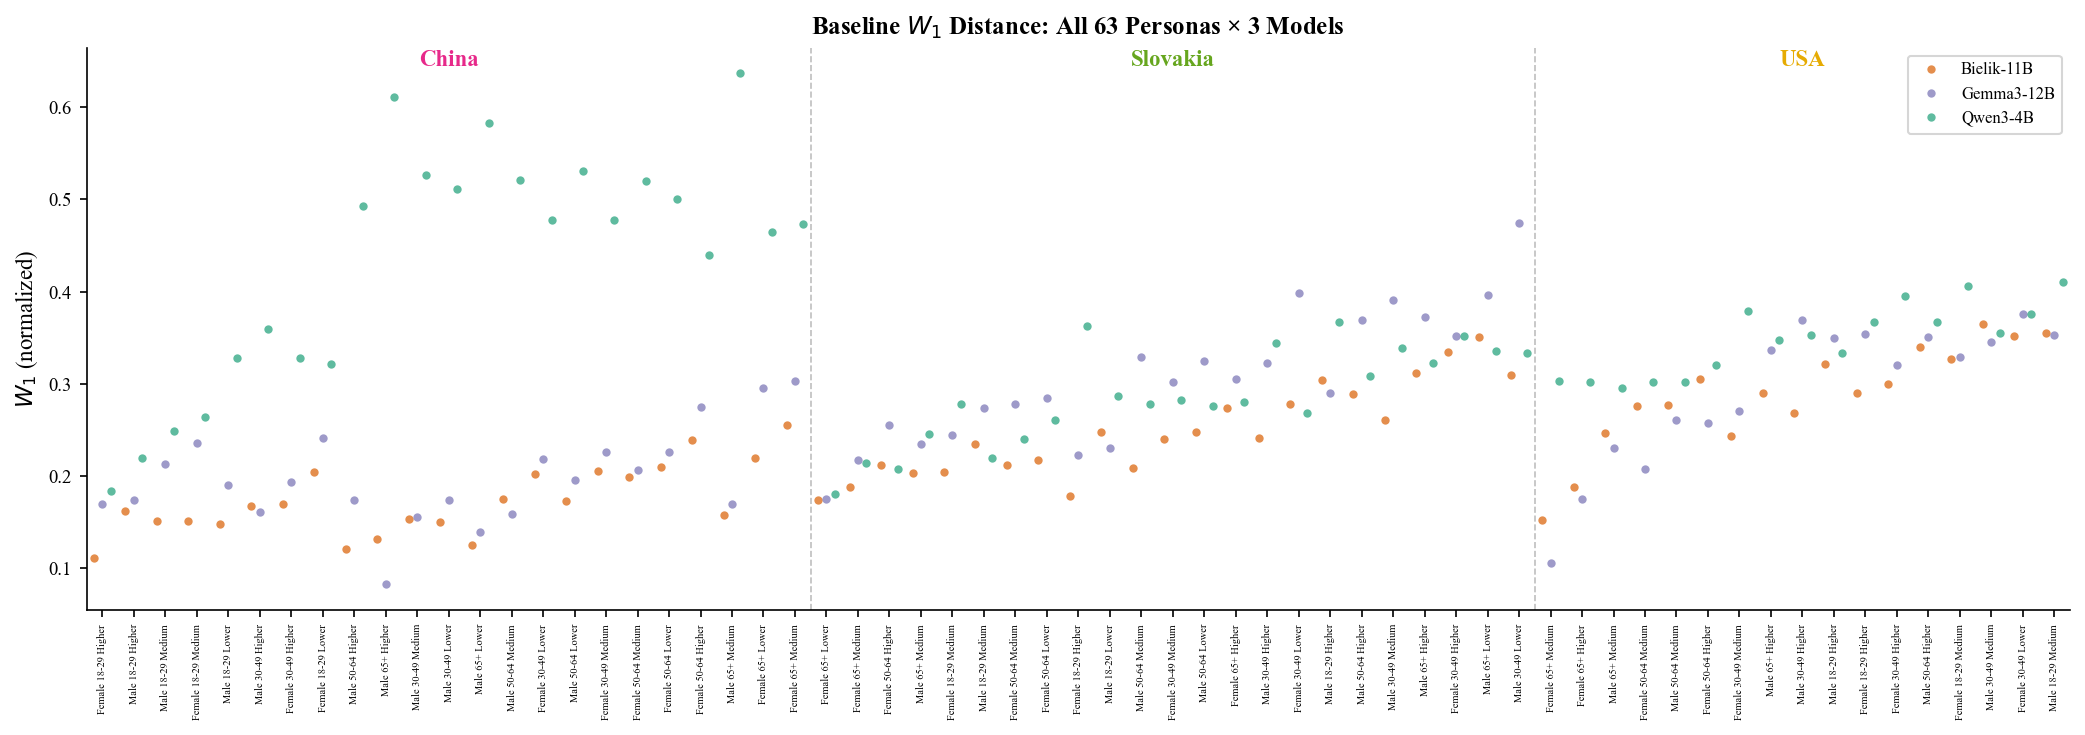

In [64]:
"""
Cell 8 — Figure A2: All 63 Personas — Baseline W₁ Strip Plot
Grouped by country, coloured by model.
"""

df_strip = w1_all.copy()
df_strip['country'] = df_strip['persona_id'].str[:3]
country_order = ['CHN', 'SVK', 'USA']
df_strip['country_rank'] = df_strip['country'].map({c: i for i, c in enumerate(country_order)})

# Sort personas: by country then by mean W1 across models
persona_means = df_strip.groupby('persona_id')['w1_norm'].mean().reset_index()
persona_means.columns = ['persona_id', 'mean_w1']
df_strip = df_strip.merge(persona_means, on='persona_id')
df_strip = df_strip.sort_values(['country_rank', 'mean_w1'])

# Ordered persona list
persona_order = df_strip.drop_duplicates('persona_id')['persona_id'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))

model_palette = {'bielik': COLORS['bielik'], 'gemma3': COLORS['gemma3'], 'qwen': COLORS['qwen']}

sns.stripplot(data=df_strip, x='persona_id', y='w1_norm', hue='model',
              order=persona_order, hue_order=['bielik', 'gemma3', 'qwen'],
              palette=model_palette, dodge=True, alpha=0.7, size=4, ax=ax, jitter=True)

# Country separators
for country in ['SVK', 'USA']:
    first_persona = df_strip[df_strip['country'] == country].drop_duplicates('persona_id')['persona_id'].iloc[0]
    idx = persona_order.index(first_persona)
    ax.axvline(x=idx - 0.5, color='gray', ls='--', lw=0.8, alpha=0.5)

# Country labels at top
for country in country_order:
    group_personas = [p for p in persona_order if p.startswith(country)]
    mid_idx = persona_order.index(group_personas[len(group_personas)//2])
    ax.text(mid_idx, ax.get_ylim()[1] * 0.97, COUNTRY_LABELS[country],
            ha='center', fontsize=11, fontweight='bold', color=COLORS[country])

ax.set_xlabel('')
ax.set_ylabel('$W_1$ (normalized)')
ax.set_title('Baseline $W_1$ Distance: All 63 Personas × 3 Models', fontweight='bold')

# Fix x-tick labels: short form, rotated
short_labels = [p.split('_', 1)[1].replace('_', ' ') for p in persona_order]
ax.set_xticks(range(len(persona_order)))
ax.set_xticklabels(short_labels, rotation=90, fontsize=5)

# Legend with full model names
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [MODEL_LABELS.get(l, l) for l in labels],
          loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
save_fig(fig, 'figA2_all_personas_strip')
plt.show()

  Saved figA3_redistribution_qwen.pdf  &  figA3_redistribution_qwen.png


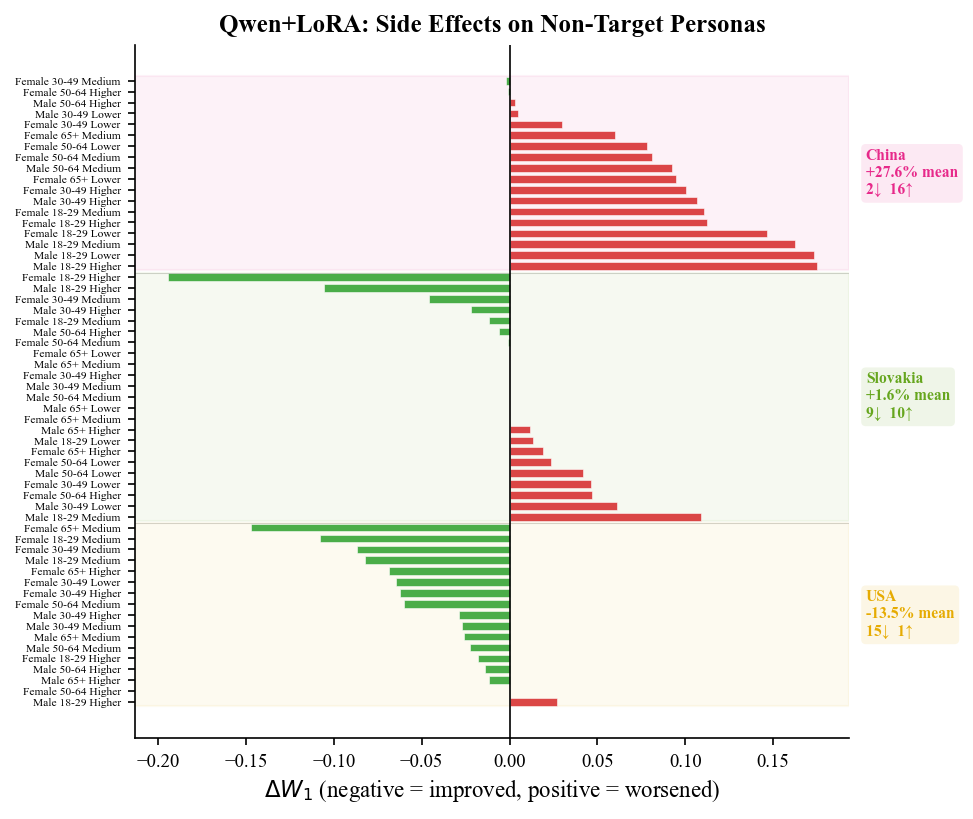

In [65]:
"""
Cell 9 — Figure A3: Qwen Redistribution (same format as Fig 4)
"""

make_redistribution_plot(
    rq3_side, 'qwen', qwen_targets,
    'Qwen+LoRA: Side Effects on Non-Target Personas',
    'figA3_redistribution_qwen'
)

  Saved figA4_education_pattern.pdf  &  figA4_education_pattern.png


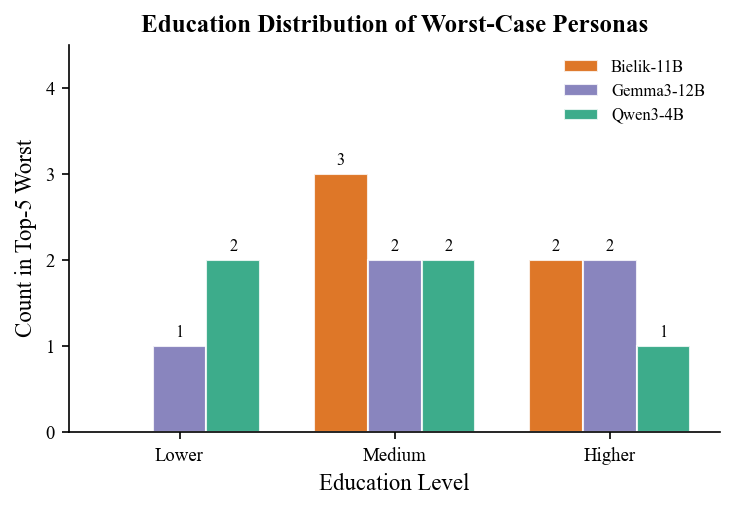

In [66]:
"""
Cell 10 — Figure A4: Education Pattern in Worst-Case Personas
Count of top-5 worst personas by education level, per model.
"""

edu_order = ['Lower', 'Medium', 'Higher']
edu_counts = top5.groupby(['model', 'education']).size().unstack(fill_value=0)
edu_counts = edu_counts.reindex(columns=edu_order, fill_value=0)
edu_counts = edu_counts.reindex(['bielik', 'gemma3', 'qwen'])

fig, ax = plt.subplots(figsize=(5, 3.5))

x = np.arange(len(edu_order))
width = 0.25
models = ['bielik', 'gemma3', 'qwen']
for i, model in enumerate(models):
    vals = edu_counts.loc[model].values
    ax.bar(x + i * width, vals, width, label=MODEL_LABELS[model],
           color=COLORS[model], alpha=0.85, edgecolor='white')
    # Value labels
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(x[j] + i * width, v + 0.1, str(int(v)), ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(edu_order)
ax.set_xlabel('Education Level')
ax.set_ylabel('Count in Top-5 Worst')
ax.set_title('Education Distribution of Worst-Case Personas', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
ax.set_ylim(0, max(edu_counts.values.max(), 4) + 0.5)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
save_fig(fig, 'figA4_education_pattern')
plt.show()

  Saved figA5_response_distributions.pdf  &  figA5_response_distributions.png


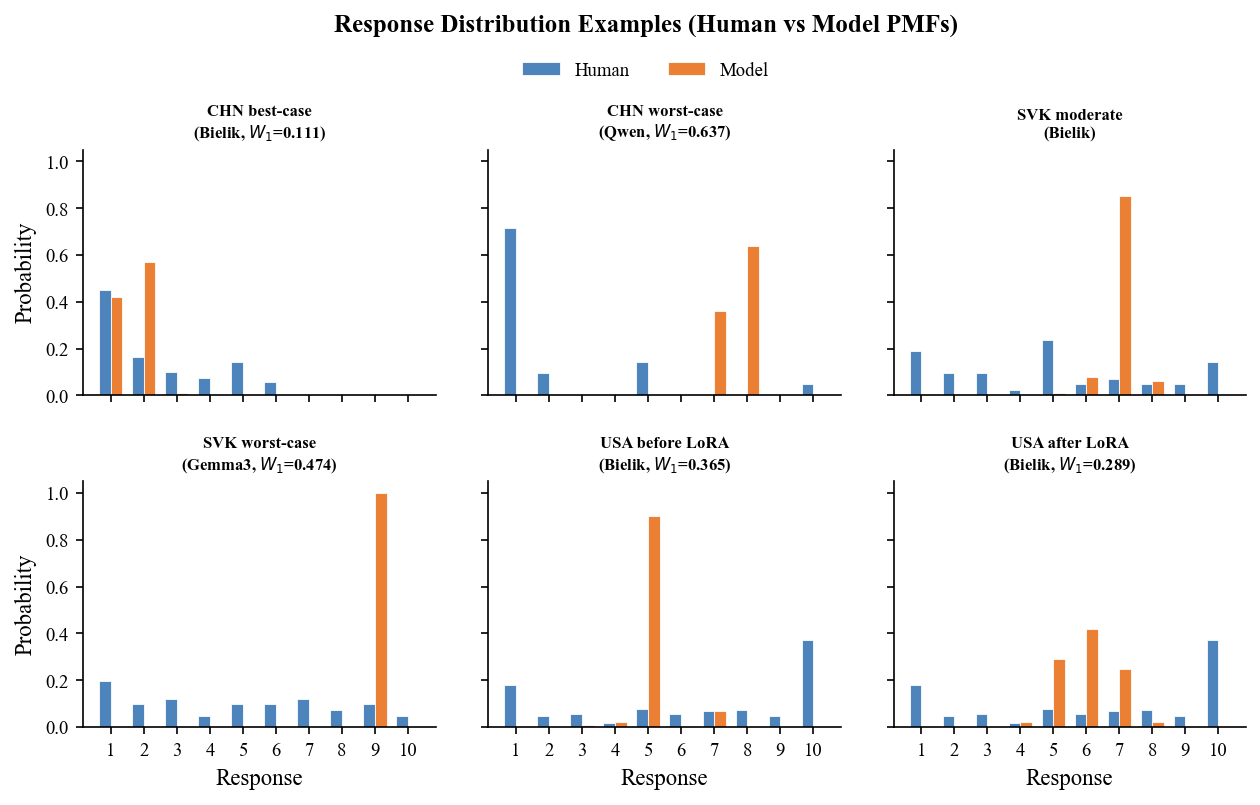

In [67]:
"""
Cell 11 — Figure A5: Response Distribution Small Multiples (6 panels)
Rows: Best-case | Worst-case | LoRA Before/After pair
Cols vary per row.
"""

# Pick informative personas
examples = [
    # (persona_id, raw_df, model_key, title)
    ('CHN_Female_18-29_Higher', baseline_bielik, 'bielik', 'CHN best-case\n(Bielik, $W_1$=0.111)'),
    ('CHN_Male_65+_Medium',     baseline_qwen,   'qwen',   'CHN worst-case\n(Qwen, $W_1$=0.637)'),
    ('SVK_Female_30-49_Higher', baseline_bielik, 'bielik', 'SVK moderate\n(Bielik)'),
    ('SVK_Male_30-49_Lower',    baseline_gemma3, 'gemma3', 'SVK worst-case\n(Gemma3, $W_1$=0.474)'),
    ('USA_Male_30-49_Medium',   baseline_bielik, 'bielik', 'USA before LoRA\n(Bielik, $W_1$=0.365)'),
    ('USA_Male_30-49_Medium',   posteval_bielik, 'bielik_lora', 'USA after LoRA\n(Bielik, $W_1$=0.289)'),
]

fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey=True)

x = np.arange(1, 11)
width = 0.35

for idx, (persona, raw_df, model_key, title) in enumerate(examples):
    r, c = divmod(idx, 3)
    ax = axes[r, c]
    
    # Human PMF
    h_row = human_dist[human_dist['persona_id'] == persona].iloc[0]
    h_pmf = h_row[pmf_cols].values.astype(float)
    
    # Model PMF
    m_pmf = get_model_pmf(raw_df, persona)
    
    ax.bar(x - width/2, h_pmf, width, color=COLORS['human'], alpha=0.8,
           label='Human', edgecolor='white', linewidth=0.5)
    ax.bar(x + width/2, m_pmf, width, color=COLORS['model'], alpha=0.8,
           label='Model', edgecolor='white', linewidth=0.5)
    
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    if r == 1:
        ax.set_xlabel('Response')
    if c == 0:
        ax.set_ylabel('Probability')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02), fontsize=9)

fig.suptitle('Response Distribution Examples (Human vs Model PMFs)',
             fontweight='bold', y=1.06)
fig.subplots_adjust(hspace=0.35, wspace=0.15)
save_fig(fig, 'figA5_response_distributions')
plt.show()

  Saved figA6_ci_vs_n.pdf  &  figA6_ci_vs_n.png


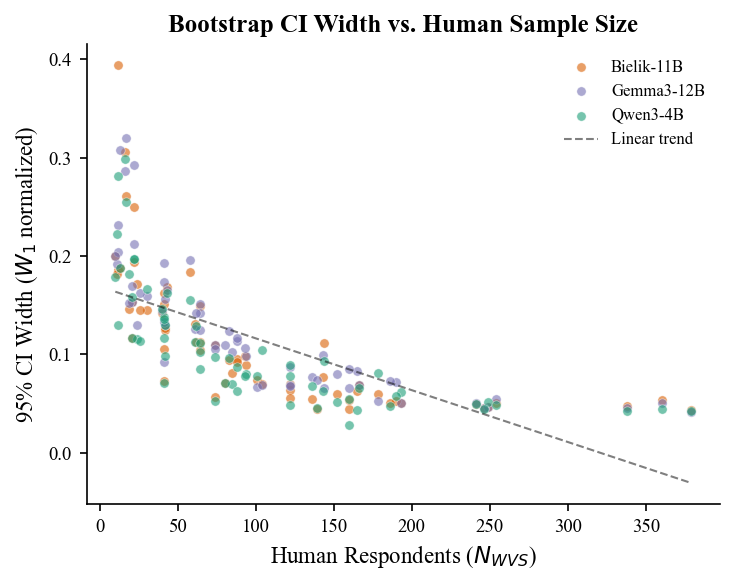

In [68]:
"""
Cell 12 — Figure A6: Bootstrap CI Width vs Human Sample Size
Scatter plot: wider CIs for personas with fewer WVS respondents.
"""

# Merge CI width with human N
ci_df = w1_ci.copy()
ci_df['ci_width'] = ci_df['w1_ci_upper'] - ci_df['w1_ci_lower']

# Get n_respondents per persona from human_dist
n_map = human_dist.set_index('persona_id')['n_respondents'].to_dict()
ci_df['n_human'] = ci_df['persona_id'].map(n_map)

fig, ax = plt.subplots(figsize=(5, 4))

model_palette = {'bielik': COLORS['bielik'], 'gemma3': COLORS['gemma3'], 'qwen': COLORS['qwen']}

for model in ['bielik', 'gemma3', 'qwen']:
    subset = ci_df[ci_df['model'] == model]
    ax.scatter(subset['n_human'], subset['ci_width'], alpha=0.6, s=20,
              color=model_palette[model], label=MODEL_LABELS[model], edgecolors='white', linewidth=0.3)

# Trend line (pooled)
valid = ci_df.dropna(subset=['n_human', 'ci_width'])
z = np.polyfit(valid['n_human'], valid['ci_width'], 1)
x_line = np.linspace(valid['n_human'].min(), valid['n_human'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.5, lw=1, label='Linear trend')

ax.set_xlabel('Human Respondents ($N_{WVS}$)')
ax.set_ylabel('95% CI Width ($W_1$ normalized)')
ax.set_title('Bootstrap CI Width vs. Human Sample Size', fontweight='bold')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
save_fig(fig, 'figA6_ci_vs_n')
plt.show()

In [69]:
"""
Cell 13 — Tables (formatted DataFrames + LaTeX export)
"""

# ── Table 1: Model Specifications ─────────────────────────────────────────────
table1 = pd.DataFrame({
    'Model': ['Bielik-11B-v3', 'Gemma3-12B', 'Qwen3-4B-Instruct'],
    'Origin': ['Poland (SpeakLeash)', 'USA (Google)', 'China (Alibaba)'],
    'Parameters': ['11B', '12B', '4B'],
    'Quantization': ['4-bit BnB', 'None', '4-bit BnB'],
    'Role': ['Baseline + LoRA', 'Baseline only', 'Baseline + LoRA'],
})
print("TABLE 1: Model Specifications")
print(table1.to_string(index=False))
print("\nLaTeX:")
print(table1.to_latex(index=False, caption='Model specifications.', label='tab:models'))

# ── Table 2: Country Profiles ─────────────────────────────────────────────────
print("\n" + "="*60)
table2 = pd.DataFrame({
    'Country': ['China', 'Slovakia', 'USA'],
    'Code': ['CHN', 'SVK', 'USA'],
    'Q164 Mean': [2.8, 6.4, 6.7],
    'Character': ['Strongly secular', 'Moderately religious', 'Highly religious'],
})
print("TABLE 2: Country Profiles (WVS Q164)")
print(table2.to_string(index=False))
print("\nLaTeX:")
print(table2.to_latex(index=False, caption='Country profiles for WVS Q164.', label='tab:countries'))

# ── Table 4: RQ2 Before/After LoRA ────────────────────────────────────────────
print("\n" + "="*60)
print("TABLE 4: RQ2 — Before/After LoRA on Target Personas")
rq2_display = rq2_comparison.copy()
rq2_display['pct_str'] = rq2_display['pct_change'].apply(lambda x: f"{x:+.1f}%")
rq2_display['delta_str'] = rq2_display['delta'].apply(lambda x: f"{x:+.4f}")
for model in ['bielik', 'qwen']:
    sub = rq2_display[rq2_display['model'] == model]
    print(f"\n  {MODEL_LABELS.get(model, model)} targets:")
    print(sub[['persona_id', 'w1_before', 'w1_after', 'delta_str', 'pct_str']].to_string(index=False))

print("\nLaTeX (Bielik):")
bielik_rq2 = rq2_display[rq2_display['model'] == 'bielik'][['persona_id', 'w1_before', 'w1_after', 'delta_str', 'pct_str']]
bielik_rq2.columns = ['Persona', '$W_1$ Before', '$W_1$ After', '$\\Delta$', '\\% Change']
print(bielik_rq2.to_latex(index=False, escape=False, caption='Bielik+LoRA: target persona results.', label='tab:rq2_bielik'))

# ── Table 5: RQ3 Country Decomposition ────────────────────────────────────────
print("\n" + "="*60)
print("TABLE 5: RQ3 — Country-Level Side Effects")
for model_name, targets in [('bielik', bielik_targets), ('qwen', qwen_targets)]:
    df = rq3_side[(rq3_side['model'] == model_name) & (~rq3_side['persona_id'].isin(targets))].copy()
    df['country'] = df['persona_id'].str[:3]
    
    summary = df.groupby('country').agg(
        n=('delta', 'size'),
        mean_delta=('delta', 'mean'),
        mean_pct=('pct_change', 'mean'),
        n_improved=('delta', lambda x: (x < 0).sum()),
        n_worsened=('delta', lambda x: (x > 0).sum()),
    ).reindex(['CHN', 'SVK', 'USA'])
    
    print(f"\n  {MODEL_LABELS.get(model_name, model_name)} non-targets:")
    print(summary.to_string())

print("\nDone generating tables.")

TABLE 1: Model Specifications
            Model              Origin Parameters Quantization            Role
    Bielik-11B-v3 Poland (SpeakLeash)        11B    4-bit BnB Baseline + LoRA
       Gemma3-12B        USA (Google)        12B         None   Baseline only
Qwen3-4B-Instruct     China (Alibaba)         4B    4-bit BnB Baseline + LoRA

LaTeX:
\begin{table}
\caption{Model specifications.}
\label{tab:models}
\begin{tabular}{lllll}
\toprule
Model & Origin & Parameters & Quantization & Role \\
\midrule
Bielik-11B-v3 & Poland (SpeakLeash) & 11B & 4-bit BnB & Baseline + LoRA \\
Gemma3-12B & USA (Google) & 12B & None & Baseline only \\
Qwen3-4B-Instruct & China (Alibaba) & 4B & 4-bit BnB & Baseline + LoRA \\
\bottomrule
\end{tabular}
\end{table}


TABLE 2: Country Profiles (WVS Q164)
 Country Code  Q164 Mean            Character
   China  CHN        2.8     Strongly secular
Slovakia  SVK        6.4 Moderately religious
     USA  USA        6.7     Highly religious

LaTeX:
\begin{table}
\

  Saved figB1_response_fingerprint.pdf  &  figB1_response_fingerprint.png


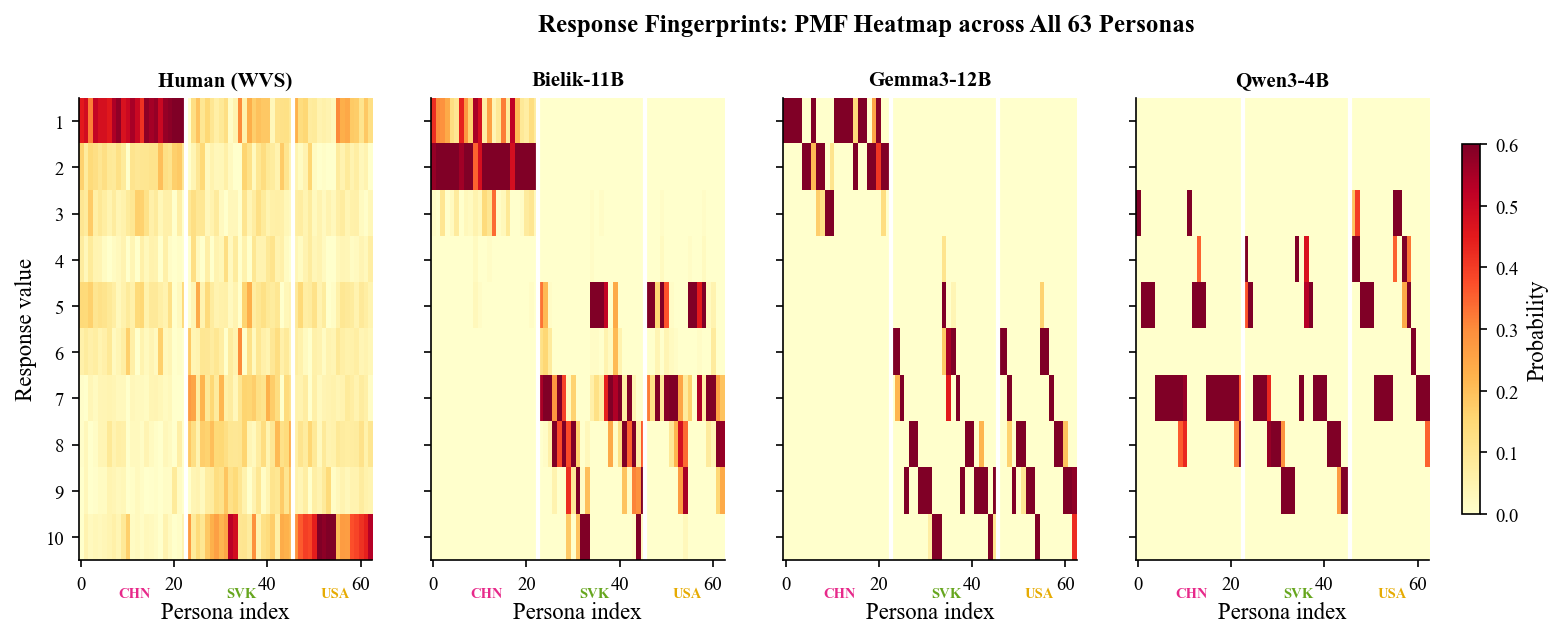

In [70]:
"""
Cell B1 — Figure B1: Response Fingerprint Heatmap
4 panels (Human | Bielik | Gemma3 | Qwen) — PMF as heatmap across all 63 personas.
Reveals RLHF overcorrection: Qwen clusters at 5-7 for secular CHN personas.
"""

def build_pmf_matrix(raw_df, persona_order):
    """Build 10×N_personas PMF matrix from raw responses."""
    matrix = np.zeros((10, len(persona_order)))
    for j, pid in enumerate(persona_order):
        mask = raw_df['persona_id'] == pid
        responses = raw_df.loc[mask, 'parsed_value'].values
        if len(responses) > 0:
            matrix[:, j] = compute_pmf_from_responses(responses)
    return matrix

# Consistent persona ordering: by country, then by persona_id
persona_order_all = sorted(human_dist['persona_id'].unique(),
                            key=lambda p: (0 if p[:3]=='CHN' else 1 if p[:3]=='SVK' else 2, p))

# Human PMF matrix (from pre-computed)
human_matrix = np.zeros((10, len(persona_order_all)))
for j, pid in enumerate(persona_order_all):
    row = human_dist[human_dist['persona_id'] == pid]
    if len(row):
        human_matrix[:, j] = row[pmf_cols].values[0]

# Model PMF matrices
bielik_matrix = build_pmf_matrix(baseline_bielik, persona_order_all)
gemma3_matrix = build_pmf_matrix(baseline_gemma3, persona_order_all)
qwen_matrix   = build_pmf_matrix(baseline_qwen,   persona_order_all)

# Country boundaries for separator lines
chn_end = sum(1 for p in persona_order_all if p[:3] == 'CHN')
svk_end = chn_end + sum(1 for p in persona_order_all if p[:3] == 'SVK')

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

titles_matrices = [
    ('Human (WVS)', human_matrix),
    ('Bielik-11B', bielik_matrix),
    ('Gemma3-12B', gemma3_matrix),
    ('Qwen3-4B',   qwen_matrix),
]

for ax, (title, matrix) in zip(axes, titles_matrices):
    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.6,
                   interpolation='nearest')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Persona index')
    
    # Country separators
    ax.axvline(x=chn_end - 0.5, color='white', lw=2)
    ax.axvline(x=svk_end - 0.5, color='white', lw=2)
    
    # Country labels at bottom
    ax.text(chn_end / 2, 10.3, 'CHN', ha='center', fontsize=7, color=COLORS['CHN'], fontweight='bold')
    ax.text((chn_end + svk_end) / 2, 10.3, 'SVK', ha='center', fontsize=7, color=COLORS['SVK'], fontweight='bold')
    ax.text((svk_end + len(persona_order_all)) / 2, 10.3, 'USA', ha='center', fontsize=7, color=COLORS['USA'], fontweight='bold')

axes[0].set_ylabel('Response value')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(range(1, 11))

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label='Probability')

fig.suptitle('Response Fingerprints: PMF Heatmap across All 63 Personas',
             fontweight='bold', y=1.02)

save_fig(fig, 'figB1_response_fingerprint')
plt.show()

  Saved figB2_cultural_distance_scatter.pdf  &  figB2_cultural_distance_scatter.png


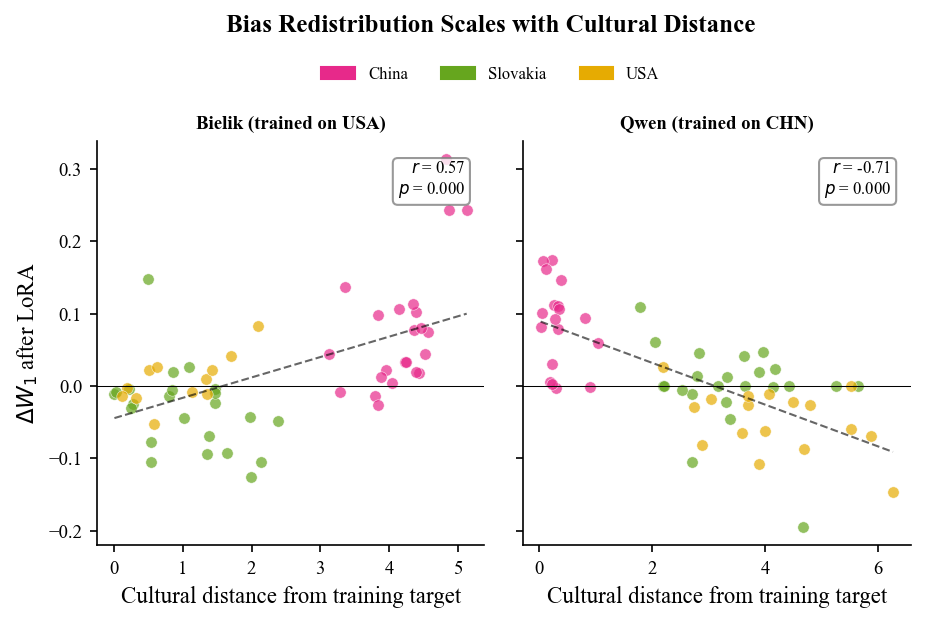

In [71]:
"""
Cell B2 — Figure B2: Cultural Distance vs ΔW₁ Scatter
X = |human_mean_persona - human_mean_target_country|
Y = ΔW₁ after LoRA
Shows that bias redistribution scales with cultural distance.
"""

# Bielik was trained on USA personas (human mean ≈ 6.7)
# Qwen was trained on CHN personas (human mean ≈ 2.8)
# Use per-persona human mean from human_distributions.csv

human_means = human_dist.set_index('persona_id')['mean_response'].to_dict()

# Country-level means for training targets
usa_mean = human_dist[human_dist['country'] == 'USA']['mean_response'].mean()
chn_mean = human_dist[human_dist['country'] == 'CHN']['mean_response'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)

for ax, model_name, targets, target_mean, target_label in [
    (ax1, 'bielik', bielik_targets, usa_mean, 'Bielik (trained on USA)'),
    (ax2, 'qwen',   qwen_targets,   chn_mean, 'Qwen (trained on CHN)'),
]:
    df = rq3_side[(rq3_side['model'] == model_name) & (~rq3_side['persona_id'].isin(targets))].copy()
    df['country'] = df['persona_id'].str[:3]
    df['human_mean'] = df['persona_id'].map(human_means)
    df['cultural_dist'] = np.abs(df['human_mean'] - target_mean)
    
    for country in ['CHN', 'SVK', 'USA']:
        sub = df[df['country'] == country]
        ax.scatter(sub['cultural_dist'], sub['delta'], color=COLORS[country],
                   alpha=0.7, s=30, label=COUNTRY_LABELS[country],
                   edgecolors='white', linewidth=0.3)
    
    # Overall regression line
    valid = df.dropna(subset=['cultural_dist', 'delta'])
    if len(valid) > 2:
        slope, intercept, r_val, p_val, _ = stats.linregress(valid['cultural_dist'], valid['delta'])
        x_line = np.linspace(valid['cultural_dist'].min(), valid['cultural_dist'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1, alpha=0.6)
        ax.text(0.95, 0.95, f'$r$ = {r_val:.2f}\n$p$ = {p_val:.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))
    
    ax.axhline(y=0, color='black', lw=0.5, ls='-')
    ax.set_xlabel('Cultural distance from training target')
    ax.set_title(target_label, fontweight='bold', fontsize=9)

ax1.set_ylabel('$\\Delta W_1$ after LoRA')

# Shared legend
handles = [mpatches.Patch(color=COLORS[c], label=COUNTRY_LABELS[c]) for c in ['CHN', 'SVK', 'USA']]
fig.legend(handles=handles, loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.05), fontsize=8)

fig.suptitle('Bias Redistribution Scales with Cultural Distance',
             fontweight='bold', y=1.12)
fig.subplots_adjust(wspace=0.1)

save_fig(fig, 'figB2_cultural_distance_scatter')
plt.show()

In [72]:
"""
Cell — Verify all figures saved
"""
import glob as glob_mod

plt.close('all')

expected = [
    'fig1_w1_explanation', 'fig2_rq1_heatmap', 'fig3_rq2_cdf_comparison',
    'fig4_rq3_redistribution_bielik', 'fig5_before_after_violin', 'fig6_top5_turnover',
    'fig7_bias_starburst',
    'figA1_prompt_template', 'figA2_all_personas_strip', 'figA3_redistribution_qwen',
    'figA4_education_pattern', 'figA5_response_distributions', 'figA6_ci_vs_n',
    'figB1_response_fingerprint', 'figB2_cultural_distance_scatter',
]

print("Figure inventory:")
print("-" * 55)
all_ok = True
for name in expected:
    pdf_exists = (FIG_DIR / f"{name}.pdf").exists()
    png_exists = (FIG_DIR / f"{name}.png").exists()
    status = "OK" if (pdf_exists and png_exists) else "MISSING"
    if status == "MISSING":
        all_ok = False
    print(f"  {name:42s} {status}")

print("-" * 55)
total_files = len(list(FIG_DIR.glob('*.*')))
print(f"Total files in figures/: {total_files}")
print(f"Status: {'ALL GOOD' if all_ok else 'SOME MISSING — re-run cells above'}")

Figure inventory:
-------------------------------------------------------
  fig1_w1_explanation                        OK
  fig2_rq1_heatmap                           OK
  fig3_rq2_cdf_comparison                    OK
  fig4_rq3_redistribution_bielik             OK
  fig5_before_after_violin                   OK
  fig6_top5_turnover                         OK
  fig7_bias_starburst                        OK
  figA1_prompt_template                      OK
  figA2_all_personas_strip                   OK
  figA3_redistribution_qwen                  OK
  figA4_education_pattern                    OK
  figA5_response_distributions               OK
  figA6_ci_vs_n                              OK
  figB1_response_fingerprint                 OK
  figB2_cultural_distance_scatter            OK
-------------------------------------------------------
Total files in figures/: 30
Status: ALL GOOD
